# 04_15 Model Evaluation Visualization

So sanh model va ve confusion matrix / bieu do do chinh xac tu artifacts da train o 04_01..04_14.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Truc quan hoa ket qua cua cac nhom model de phuc vu bao cao cuoi ky.
- Muc tieu ky thuat: Ve confusion matrix, metric chart va hien thi bang metric tong hop ngay trong notebook.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegressionModel, RandomForestClassificationModel, NaiveBayesModel, LinearSVCModel, GBTClassificationModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = (SparkSession.builder.appName('04_15_eval_viz').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
FEATURE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'features'
MODEL_ROOT = PROJECT_ROOT / 'models'
METRIC_DIR = PROJECT_ROOT / 'reports' / 'model_metrics'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

metric_rows = []
for metric_file in sorted(METRIC_DIR.glob('*.json')):
    try:
        metric_rows.append(json.loads(metric_file.read_text(encoding='utf-8')))
    except Exception:
        pass
metrics_pdf = pd.DataFrame(metric_rows)
if not metrics_pdf.empty:
    print('Bang metric tong hop (doc tu JSON):')
    display(metrics_pdf)
else:
    print('No metric json found in reports/model_metrics')


26/04/05 18:19:42 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 10.178.74.160 instead (on interface en0)
26/04/05 18:19:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/05 18:19:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/05 18:19:43 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Bang metric tong hop (doc tu JSON):


,model_family,model_name,val_f1,val_accuracy,val_precision,val_recall,f1,accuracy,precision,recall,...,mae,r2,test_mae,test_r2,cv_avg_r2,metric,avgMetrics,bestParams,parallelism,allParams
0,classification,DecisionTreeClassifier,0.825833,0.829177,0.823200,0.829177,0.836010,0.838026,0.834245,0.838026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,classification,GBTClassifier,0.849413,0.854586,0.846669,0.854586,0.859795,0.863703,0.857278,0.863703,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,classification,GBTClassifier_CV,0.667472,0.768184,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,classification,LinearSVC,0.856916,0.865111,0.855537,0.865111,0.863460,0.871279,0.861487,0.871279,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,classification,LogisticRegression,0.852949,0.870274,0.864840,0.870274,0.861206,0.877849,0.871039,0.877849,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,classification,LogisticRegression_CV,0.667472,0.768184,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,classification,NaiveBayes,0.855097,0.866519,0.856461,0.866519,0.860787,0.871346,0.860369,0.871346,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,classification,RandomForestClassifier,0.831845,0.832328,0.831379,0.832328,0.841803,0.841110,0.842529,0.841110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,classification,RandomForest_CV,0.667472,0.768184,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,clustering,BisectingKMeans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


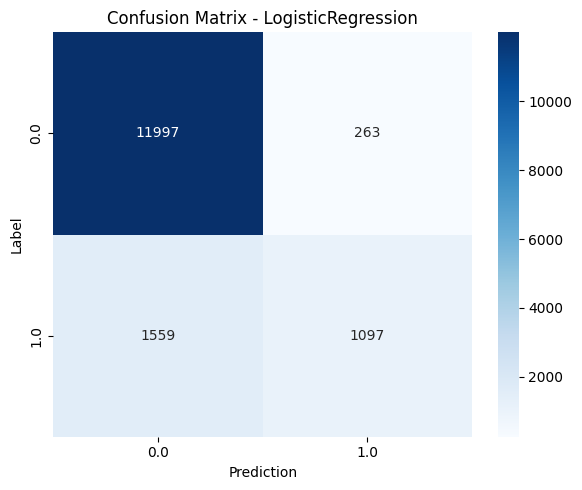

Saved: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/figures/confusion_matrix_LogisticRegression.png


26/04/05 18:19:53 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/04/05 18:19:54 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/04/05 18:19:55 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/04/05 18:19:55 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/04/05 18:19:56 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
26/04/05 18:19:57 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB


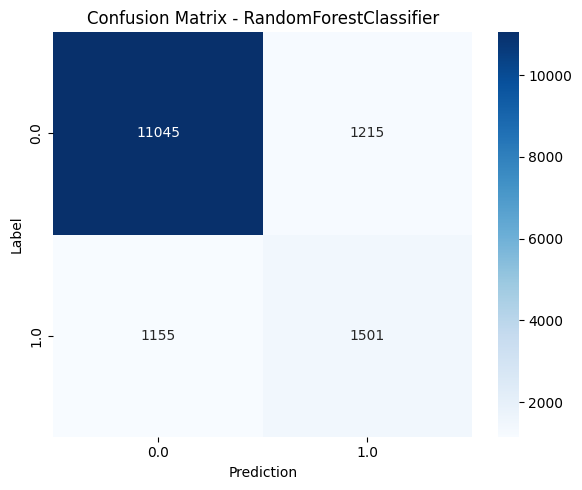

Saved: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/figures/confusion_matrix_RandomForestClassifier.png


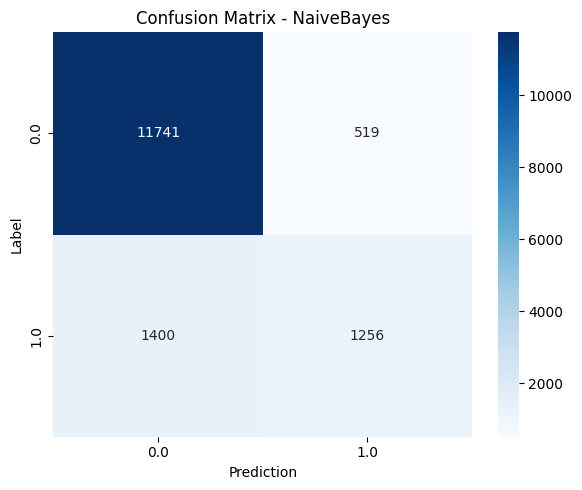

Saved: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/figures/confusion_matrix_NaiveBayes.png


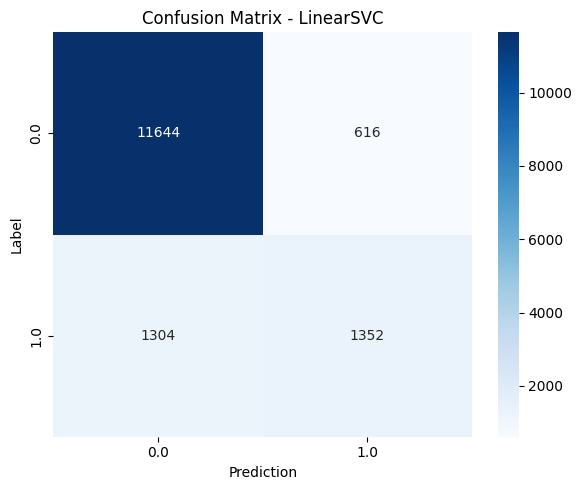

Saved: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/figures/confusion_matrix_LinearSVC.png


26/04/05 18:19:59 WARN DAGScheduler: Broadcasting large task binary with size 1177.1 KiB
26/04/05 18:19:59 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/05 18:19:59 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/04/05 18:19:59 WARN DAGScheduler: Broadcasting large task binary with size 1177.1 KiB
26/04/05 18:19:59 WARN DAGScheduler: Broadcasting large task binary with size 1177.1 KiB
26/04/05 18:19:59 WARN DAGScheduler: Broadcasting large task binary with size 1177.1 KiB
26/04/05 18:19:59 WARN DAGScheduler: Broadcasting large task binary with size 1187.2 KiB
26/04/05 18:20:00 WARN DAGScheduler: Broadcasting large task binary with size 1184.3 KiB


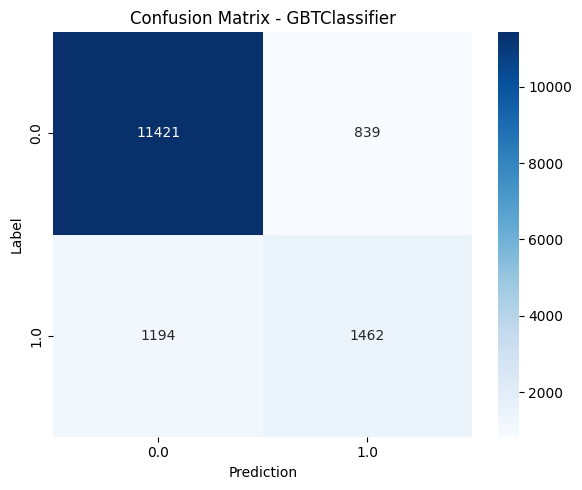

Saved: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/figures/confusion_matrix_GBTClassifier.png

=== Classification comparison (full table) ===


,model_name,accuracy,weighted_precision,weighted_recall,weighted_f1,class1_precision,class1_recall,class1_f1
0,LogisticRegression,0.877849,0.871039,0.877849,0.861206,0.806618,0.413027,0.546315
1,NaiveBayes,0.871346,0.860369,0.871346,0.860787,0.707606,0.472892,0.566915
2,LinearSVC,0.871279,0.861487,0.871279,0.863460,0.686992,0.509036,0.584775
3,GBTClassifier,0.863703,0.857278,0.863703,0.859795,0.635376,0.550452,0.589873
4,RandomForestClassifier,0.841110,0.842529,0.841110,0.841803,0.552651,0.565136,0.558824


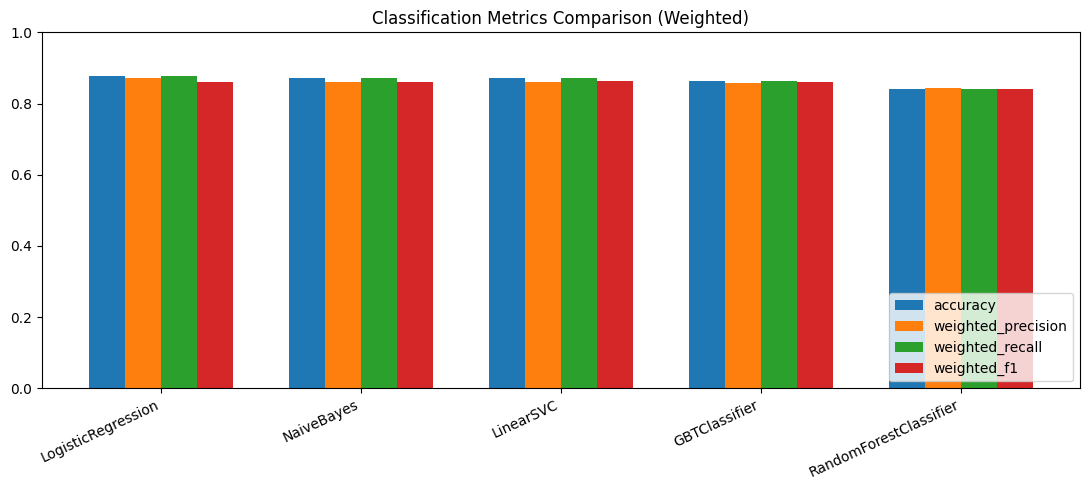

Saved: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/figures/classification_metrics_comparison.png


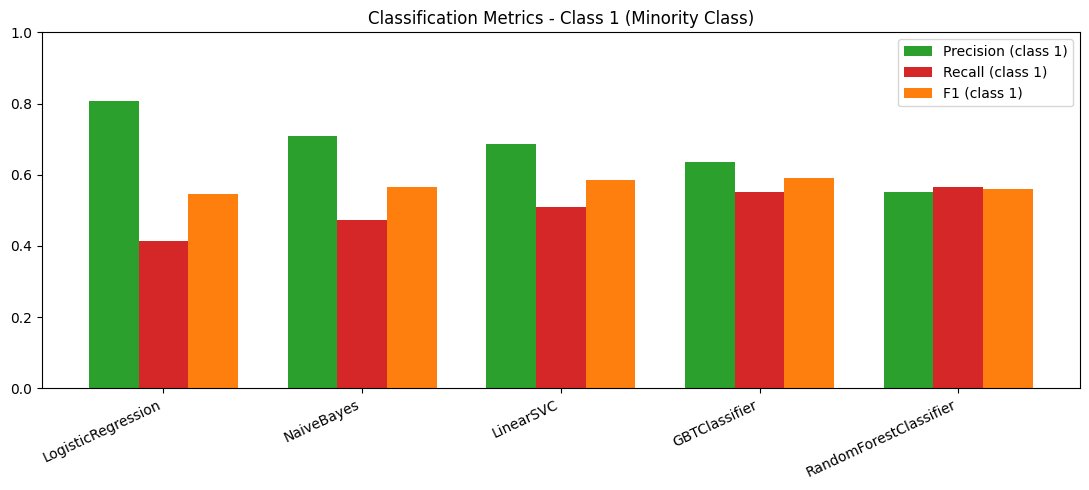

Saved: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/figures/classification_metrics_class1.png
Saved: reports/classification_metrics_comparison.csv


In [2]:
# Classification: confusion matrix + metric chart (weighted + per-class)
cls_path = FEATURE_DIR / 'classification_test'
if cls_path.exists():
    test_df = spark.read.parquet(str(cls_path)).select('order_id', 'label', 'features').dropna().cache()

    model_specs = [
        ('LogisticRegression', MODEL_ROOT / 'classification' / 'logistic_regression', LogisticRegressionModel),
        ('RandomForestClassifier', MODEL_ROOT / 'classification' / 'random_forest', RandomForestClassificationModel),
        ('NaiveBayes', MODEL_ROOT / 'classification' / 'naive_bayes', NaiveBayesModel),
        ('LinearSVC', MODEL_ROOT / 'classification' / 'linear_svc', LinearSVCModel),
        ('GBTClassifier', MODEL_ROOT / 'classification' / 'gbt_classifier', GBTClassificationModel),
    ]

    evaluator_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1')
    evaluator_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
    evaluator_precision = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision')
    evaluator_recall = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall')

    def is_model_artifact_ready(model_path: Path) -> bool:
        return (model_path / 'metadata').exists()

    cls_metric_rows = []
    for model_name, model_path, model_cls in model_specs:
        if not is_model_artifact_ready(model_path):
            print(f'Skip {model_name}: metadata missing at {model_path / "metadata"}')
            continue

        try:
            model = model_cls.load(str(model_path))
        except Exception as e:
            print(f'Skip {model_name}: cannot load model at {model_path} -> {e}')
            continue
        pred = model.transform(test_df).select('label', 'prediction')

        # Weighted metrics (overall)
        f1 = evaluator_f1.evaluate(pred)
        acc = evaluator_acc.evaluate(pred)
        precision = evaluator_precision.evaluate(pred)
        recall = evaluator_recall.evaluate(pred)

        # Per-class metrics from confusion matrix
        cm_sdf = pred.groupBy('label', 'prediction').count()
        cm_pdf = cm_sdf.toPandas()

        # Compute class-1 metrics (minority class)
        tp = cm_pdf[(cm_pdf['label'] == 1.0) & (cm_pdf['prediction'] == 1.0)]['count'].sum()
        fp = cm_pdf[(cm_pdf['label'] == 0.0) & (cm_pdf['prediction'] == 1.0)]['count'].sum()
        fn = cm_pdf[(cm_pdf['label'] == 1.0) & (cm_pdf['prediction'] == 0.0)]['count'].sum()
        tn = cm_pdf[(cm_pdf['label'] == 0.0) & (cm_pdf['prediction'] == 0.0)]['count'].sum()

        prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec_1 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_1 = 2 * prec_1 * rec_1 / (prec_1 + rec_1) if (prec_1 + rec_1) > 0 else 0.0

        cls_metric_rows.append({
            'model_name': model_name,
            'accuracy': float(acc),
            'weighted_precision': float(precision),
            'weighted_recall': float(recall),
            'weighted_f1': float(f1),
            'class1_precision': float(prec_1),
            'class1_recall': float(rec_1),
            'class1_f1': float(f1_1),
        })

        # Confusion matrix heatmap
        if not cm_pdf.empty:
            cm_table = cm_pdf.pivot(index='label', columns='prediction', values='count').fillna(0)
            cm_table = cm_table.sort_index().sort_index(axis=1)

            plt.figure(figsize=(6, 5))
            sns.heatmap(cm_table, annot=True, fmt='.0f', cmap='Blues')
            plt.title(f'Confusion Matrix - {model_name}')
            plt.xlabel('Prediction')
            plt.ylabel('Label')
            plt.tight_layout()
            out_path = FIG_DIR / f'confusion_matrix_{model_name}.png'
            plt.savefig(out_path, dpi=150)
            plt.show()
            print(f'Saved: {out_path}')

    cls_metrics_pdf = pd.DataFrame(cls_metric_rows)
    if (not cls_metrics_pdf.empty) and ('accuracy' in cls_metrics_pdf.columns):
        cls_metrics_pdf = cls_metrics_pdf.sort_values('accuracy', ascending=False).reset_index(drop=True)
        print('\n=== Classification comparison (full table) ===')
        display(cls_metrics_pdf)

        # --- Chart 1: Weighted metrics (overall) ---
        plt.figure(figsize=(11, 5))
        x = range(len(cls_metrics_pdf))
        w = 0.18
        plt.bar([i - 0.27 for i in x], cls_metrics_pdf['accuracy'], width=w, label='accuracy')
        plt.bar([i - 0.09 for i in x], cls_metrics_pdf['weighted_precision'], width=w, label='weighted_precision')
        plt.bar([i + 0.09 for i in x], cls_metrics_pdf['weighted_recall'], width=w, label='weighted_recall')
        plt.bar([i + 0.27 for i in x], cls_metrics_pdf['weighted_f1'], width=w, label='weighted_f1')
        plt.xticks(list(x), cls_metrics_pdf['model_name'], rotation=25, ha='right')
        plt.ylim(0, 1)
        plt.title('Classification Metrics Comparison (Weighted)')
        plt.legend(loc='lower right')
        plt.tight_layout()
        out1 = FIG_DIR / 'classification_metrics_comparison.png'
        plt.savefig(out1, dpi=150)
        plt.show()
        print(f'Saved: {out1}')

        # --- Chart 2: Per-class metrics for CLASS 1 (minority) ---
        plt.figure(figsize=(11, 5))
        w = 0.25
        plt.bar([i - 0.25 for i in x], cls_metrics_pdf['class1_precision'], width=w, label='Precision (class 1)', color='#2ca02c')
        plt.bar(list(x), cls_metrics_pdf['class1_recall'], width=w, label='Recall (class 1)', color='#d62728')
        plt.bar([i + 0.25 for i in x], cls_metrics_pdf['class1_f1'], width=w, label='F1 (class 1)', color='#ff7f0e')
        plt.xticks(list(x), cls_metrics_pdf['model_name'], rotation=25, ha='right')
        plt.ylim(0, 1)
        plt.title('Classification Metrics - Class 1 (Minority Class)')
        plt.legend(loc='upper right')
        plt.tight_layout()
        out2 = FIG_DIR / 'classification_metrics_class1.png'
        plt.savefig(out2, dpi=150)
        plt.show()
        print(f'Saved: {out2}')

        cls_metrics_pdf.to_csv(PROJECT_ROOT / 'reports' / 'classification_metrics_comparison.csv', index=False)
        print('Saved: reports/classification_metrics_comparison.csv')
    else:
        print('No classification model loaded successfully; skip classification comparison chart.')
else:
    print('Missing features/classification_test, skip classification visualization')

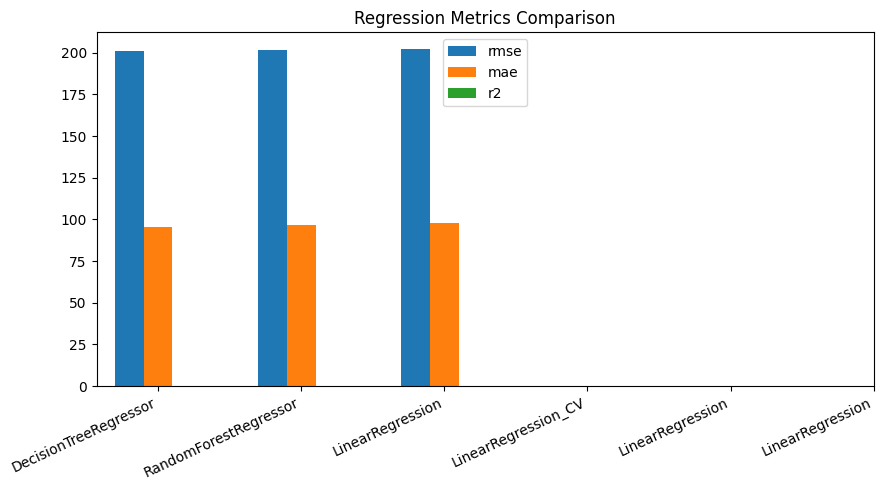

Saved: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/figures/regression_metrics_comparison.png


In [3]:
# Regression / clustering / ALS / FP summary charts from metric JSON
if metrics_pdf.empty:
    print('No metric rows to visualize.')
else:
    reg_pdf = metrics_pdf[metrics_pdf.get('model_family', pd.Series(dtype=str)) == 'regression'].copy()
    if not reg_pdf.empty and {'rmse','mae','r2'}.issubset(set(reg_pdf.columns)):
        reg_pdf = reg_pdf.sort_values('rmse', ascending=True)
        plt.figure(figsize=(9,5))
        x = range(len(reg_pdf))
        plt.bar([i - 0.2 for i in x], reg_pdf['rmse'], width=0.2, label='rmse')
        plt.bar(x, reg_pdf['mae'], width=0.2, label='mae')
        plt.bar([i + 0.2 for i in x], reg_pdf['r2'], width=0.2, label='r2')
        plt.xticks(list(x), reg_pdf['model_name'], rotation=25, ha='right')
        plt.title('Regression Metrics Comparison')
        plt.legend()
        plt.tight_layout()
        out = FIG_DIR / 'regression_metrics_comparison.png'
        plt.savefig(out, dpi=150)
        plt.show()
        print(f'Saved: {out}')

    clu_pdf = metrics_pdf[metrics_pdf.get('model_family', pd.Series(dtype=str)) == 'clustering'].copy()
    if not clu_pdf.empty and 'silhouette' in clu_pdf.columns:
        clu_pdf = clu_pdf.sort_values('silhouette', ascending=False)
        plt.figure(figsize=(8,4))
        plt.bar(clu_pdf['model_name'], clu_pdf['silhouette'])
        plt.ylim(0, 1)
        plt.title('Clustering Silhouette Comparison')
        plt.xticks(rotation=25, ha='right')
        plt.tight_layout()
        out = FIG_DIR / 'clustering_silhouette_comparison.png'
        plt.savefig(out, dpi=150)
        plt.show()
        print(f'Saved: {out}')
